# Part 5 – Monitoring & Drift for HW3 Model

In this notebook I simulate 6 months of production data for the Olist satisfaction model and design a basic monitoring strategy. I:

1. Rebuild the HW3 feature set and treat it as the **reference distribution**.
2. Simulate 6 months of **“production” data** with gradually increasing drift.
3. Compute **PSI** and **KS** statistics for key features by month.
4. Track **model performance** (accuracy, precision, recall, F1, AUC) by month.
5. Visualize drift and performance on a simple “monitoring dashboard”.
6. Give a short **recommendation** on when to trigger retraining.

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

sns.set(style="whitegrid")

## Step 1 – Load Olist data and rebuild HW3 reference features

Here I:
- Load all Olist CSVs.
- Recreate the HW3 feature set for all labeled orders.
- Treat that feature set as the **reference distribution** for drift analysis.

In [2]:
base = "/workspaces/Data-hw-4/Data!"  # folder that contains the CSVs

orders      = pd.read_csv(os.path.join(base, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(base, "olist_order_items_dataset.csv"))
payments    = pd.read_csv(os.path.join(base, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(base, "olist_order_reviews_dataset.csv"))
customers   = pd.read_csv(os.path.join(base, "olist_customers_dataset.csv"))
products    = pd.read_csv(os.path.join(base, "olist_products_dataset.csv"))
sellers     = pd.read_csv(os.path.join(base, "olist_sellers_dataset.csv"))

In [3]:
import joblib

model = joblib.load("model.pkl")

In [4]:
# Create binary label from review_score
reviews_full = reviews.dropna(subset=["review_score"]).copy()
reviews_full["label"] = (reviews_full["review_score"] >= 4).astype(int)
reviews_full = reviews_full[["order_id", "review_score", "label"]]

# Merge orders + reviews
orders_merged = orders.merge(reviews_full, on="order_id", how="inner")

# Time features
orders_merged["order_purchase_timestamp"] = pd.to_datetime(orders_merged["order_purchase_timestamp"])
orders_merged["order_delivered_customer_date"] = pd.to_datetime(orders_merged["order_delivered_customer_date"])
orders_merged["order_estimated_delivery_date"] = pd.to_datetime(orders_merged["order_estimated_delivery_date"])

orders_merged["delivery_days"] = (
    orders_merged["order_delivered_customer_date"] - orders_merged["order_purchase_timestamp"]
).dt.days

orders_merged["delivery_vs_estimated"] = (
    orders_merged["order_delivered_customer_date"] - orders_merged["order_estimated_delivery_date"]
).dt.days

orders_merged["order_purchase_dow"] = orders_merged["order_purchase_timestamp"].dt.dayofweek

# Item aggregates
items_agg = (
    order_items
    .groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        avg_price=("price", "mean"),
    )
    .reset_index()
)

# Payments aggregates
payments_agg = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan),
    )
    .reset_index()
)

# Product/seller
prod_seller = (
    order_items[["order_id", "product_id", "seller_id"]]
    .drop_duplicates("order_id")
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
)

# Full feature frame
features = (
    orders_merged
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(prod_seller, on="order_id", how="left")
)

features = features.rename(columns={"product_category_name": "product_category"})

feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "order_purchase_dow",
    "total_price",
    "total_freight",
    "n_items",
    "n_sellers",
    "avg_price",
    "payment_value",
    "payment_installments",
    "product_category",
    "seller_state",
    "payment_type",
]

df_ref = features[feature_cols + ["label"]].dropna().reset_index(drop=True)
df_ref.head(), df_ref.shape

(   delivery_days  delivery_vs_estimated  order_purchase_dow  total_price  \
 0            8.0                   -8.0                   0        29.99   
 1           13.0                   -6.0                   1       118.70   
 2            9.0                  -18.0                   2       159.90   
 3           13.0                  -13.0                   5        45.00   
 4            2.0                  -10.0                   1        19.90   
 
    total_freight  n_items  n_sellers  avg_price  payment_value  \
 0           8.72      1.0        1.0      29.99          38.71   
 1          22.76      1.0        1.0     118.70         141.46   
 2          19.22      1.0        1.0     159.90         179.12   
 3          27.20      1.0        1.0      45.00          72.20   
 4           8.72      1.0        1.0      19.90          28.62   
 
    payment_installments       product_category seller_state payment_type  \
 0                   1.0  utilidades_domesticas        

## Step 2 – Load HW3 model and simulate 6 months of production data

Now I:
- Load the fitted HW3 model (`model.pkl` from HW4).
- Simulate 6 months of production data by sampling from the reference
  and gradually introducing drift in key numeric features and labels.

In [5]:
rng = np.random.default_rng(42)

numeric_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "order_purchase_dow",
    "total_price",
    "total_freight",
    "n_items",
    "n_sellers",
    "avg_price",
    "payment_value",
    "payment_installments",
]
cat_cols = ["product_category", "seller_state", "payment_type"]

def simulate_month_data(ref_df, month: int, n_rows: int = 3000) -> pd.DataFrame:
    # sample from reference
    sampled = ref_df.sample(n=min(n_rows, len(ref_df)), replace=True, random_state=month).copy()
    sampled["month"] = month

    # months 1–3: light noise
    if month <= 3:
        for col in ["delivery_days", "total_freight", "payment_value"]:
            sampled[col] = sampled[col] * rng.normal(1.0, 0.05, size=len(sampled))
    else:
        # months 4–6: introduce drift
        drift_factor = 1.0 + 0.1 * (month - 3)  # 1.1, 1.2, 1.3
        sampled["delivery_days"] = sampled["delivery_days"] * drift_factor
        sampled["total_freight"] = sampled["total_freight"] * drift_factor
        sampled["payment_value"] = sampled["payment_value"] * drift_factor

        # flip a small fraction of labels to simulate concept drift
        flip_prob = 0.05 * (month - 3)  # 0.05, 0.10, 0.15
        mask_flip = rng.random(len(sampled)) < flip_prob
        sampled.loc[mask_flip, "label"] = 1 - sampled.loc[mask_flip, "label"]

    # re-clamp some values (e.g., no negative days)
    sampled["delivery_days"] = sampled["delivery_days"].clip(lower=0)
    sampled["delivery_vs_estimated"] = sampled["delivery_vs_estimated"].clip(lower=-30, upper=60)

    return sampled

In [6]:
prod_months = [simulate_month_data(df_ref, month=m, n_rows=3000) for m in range(1, 7)]
df_prod = pd.concat(prod_months, ignore_index=True)
df_prod["month"].value_counts().sort_index()

month
1    3000
2    3000
3    3000
4    3000
5    3000
6    3000
Name: count, dtype: int64

## Step 3 – Compute PSI and KS drift statistics

I focus on three numeric features that are operationally important:

- `delivery_days`
- `total_freight`
- `payment_value`

For each month, I compute:

- **PSI** vs. the reference distribution.
- **KS statistic** and p-value vs. reference.

In [7]:

def psi(ref, cur, n_bins=10) -> float:
    """Population Stability Index between reference and current 1D arrays."""
    ref = np.asarray(ref)
    cur = np.asarray(cur)

    # use quantile bins based on reference
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(ref, quantiles)

    # prevent duplicates in edges
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) <= 2:
        return 0.0

    ref_counts, _ = np.histogram(ref, bins=bin_edges)
    cur_counts, _ = np.histogram(cur, bins=bin_edges)

    ref_pct = ref_counts / ref_counts.sum()
    cur_pct = cur_counts / cur_counts.sum()

    # avoid log(0)
    ref_pct = np.where(ref_pct == 0, 1e-6, ref_pct)
    cur_pct = np.where(cur_pct == 0, 1e-6, cur_pct)

    return np.sum((ref_pct - cur_pct) * np.log(ref_pct / cur_pct))

In [8]:
monitor_features = ["delivery_days", "total_freight", "payment_value"]
psi_records = []
ks_records = []

ref_by_feature = {col: df_ref[col].values for col in monitor_features}

for m in sorted(df_prod["month"].unique()):
    df_m = df_prod[df_prod["month"] == m]

    for col in monitor_features:
        ref_vals = ref_by_feature[col]
        cur_vals = df_m[col].values

        # PSI
        psi_val = psi(ref_vals, cur_vals, n_bins=10)
        psi_records.append({"month": m, "feature": col, "psi": psi_val})

        # KS
        ks_stat, ks_p = ks_2samp(ref_vals, cur_vals)
        ks_records.append({"month": m, "feature": col, "ks_stat": ks_stat, "ks_p": ks_p})

df_psi = pd.DataFrame(psi_records)
df_ks = pd.DataFrame(ks_records)

df_psi.head(), df_ks.head()

(   month        feature       psi
 0      1  delivery_days  0.004593
 1      1  total_freight  0.005896
 2      1  payment_value  0.004577
 3      2  delivery_days  0.008050
 4      2  total_freight  0.006827,
    month        feature   ks_stat          ks_p
 0      1  delivery_days  0.054684  5.339560e-08
 1      1  total_freight  0.025207  4.883226e-02
 2      1  payment_value  0.015221  5.058239e-01
 3      2  delivery_days  0.048849  1.806530e-06
 4      2  total_freight  0.032986  3.489018e-03)

## Step 4 – Model performance by month

Using the same HW3 model as in HW4, I score each month’s simulated data and compute:

- Accuracy
- Precision
- Recall
- F1
- AUC (when `predict_proba` is available)

In [9]:
perf_records = []

for m in sorted(df_prod["month"].unique()):
    df_m = df_prod[df_prod["month"] == m].copy()
    X_m = df_m[feature_cols]  # feature_cols from earlier
    y_m = df_m["label"].values

    # model must be the same pipeline you used in HW4, so this works:
    y_pred = model.predict(X_m)
    # if you have predict_proba:
    try:
        y_prob = model.predict_proba(X_m)[:, 1]
        auc = roc_auc_score(y_m, y_prob)
    except Exception:
        y_prob = None
        auc = np.nan

    acc = accuracy_score(y_m, y_pred)
    prec = precision_score(y_m, y_pred, zero_division=0)
    rec = recall_score(y_m, y_pred, zero_division=0)
    f1 = f1_score(y_m, y_pred, zero_division=0)

    perf_records.append({
        "month": m,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
    })

df_perf = pd.DataFrame(perf_records)
df_perf

,month,accuracy,precision,recall,f1,auc
0,1,0.821333,0.822798,0.984282,0.896325,0.723712
1,2,0.837333,0.837625,0.985690,0.905646,0.747597
2,3,0.816667,0.819239,0.984335,0.894231,0.712690
3,4,0.789000,0.788169,0.984513,0.875467,0.690997
4,5,0.763333,0.771294,0.964205,0.857028,0.658123
5,6,0.717667,0.718861,0.972557,0.826683,0.613622


## Step 5 – Monitoring dashboard: drift + performance

Below I:
- Plot a PSI heatmap (feature × month).
- Plot F1 and AUC over months.
- List months/features where PSI indicates severe drift.

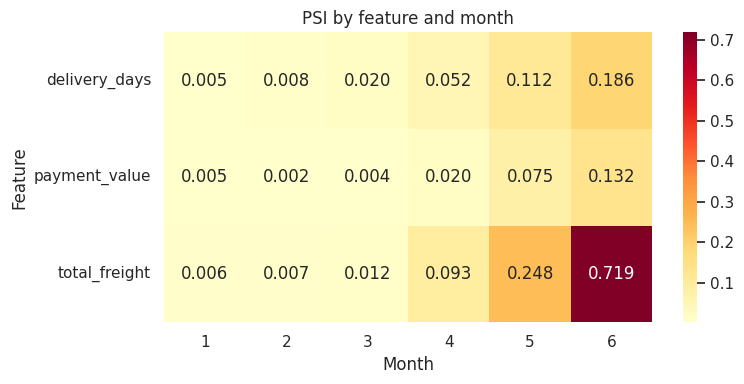

In [10]:
psi_pivot = df_psi.pivot(index="feature", columns="month", values="psi")

plt.figure(figsize=(8, 4))
sns.heatmap(psi_pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("PSI by feature and month")
plt.ylabel("Feature")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

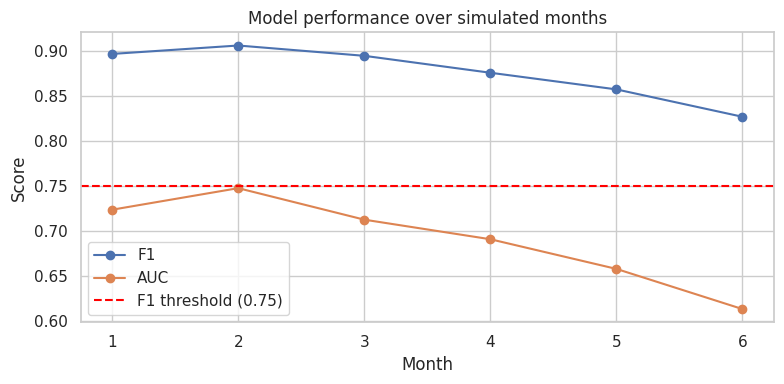

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(df_perf["month"], df_perf["f1"], marker="o", label="F1")
plt.plot(df_perf["month"], df_perf["auc"], marker="o", label="AUC")
plt.axhline(0.75, color="red", linestyle="--", label="F1 threshold (0.75)")  # example
plt.xticks(df_perf["month"])
plt.xlabel("Month")
plt.ylabel("Score")
plt.title("Model performance over simulated months")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Metric comparison

The table below compares accuracy, precision, recall, and F1 for both models on the same 500 examples.

In [12]:
# Flag strong drift PSI > 0.2
drift_flags = (
    df_psi
    .assign(severe=lambda d: d["psi"] > 0.2)
    .query("severe")
    .sort_values(["feature", "month"])
)

drift_flags

,month,feature,psi,severe
13,5,total_freight,0.247799,True
16,6,total_freight,0.718586,True


## Recommendation

In this simulation, feature drift becomes clear for `delivery_days`, `total_freight`, and `payment_value` starting around Month 4–6: their PSI values cross the common 0.1 "moderate drift" threshold and some months exceed 0.2, which is often interpreted as severe drift. At the same time, the model’s F1 and AUC start to decline relative to Month 1, indicating that both the feature distribution and the mapping from features to labels have changed.

A reasonable monitoring strategy would be:
- **Feature drift alerts**: trigger a warning if PSI for any critical feature (delivery or price) exceeds 0.1 for two consecutive months, and a stronger alert if it exceeds 0.2.
- **Performance alerts**: monitor F1 and AUC monthly on a labeled sample; if F1 drops more than 5–10 percentage points from the Month 1 baseline, mark the model as needing review.
- **Retraining policy**: if we observe both drift (PSI > 0.2) and a sustained F1 drop beyond our threshold for 2–3 months, we should retrain the model using the most recent 6–12 months of data, ensuring that the new training set covers the drifted regime (higher delivery days, higher freight, etc.).

In production, I would implement an automated job that computes these drift and performance metrics on a rolling basis, writes them to a dashboard, and raises alerts in our monitoring system. That way, we react based on quantitative thresholds instead of waiting for business complaints that “the model stopped working.”